# **Plots for Questionnaire based Data Quality Assessment**




Adapted from
* Journey to Data Quality Chapter 3: *Assessing Data Quality, Part I* (2009). Yang W. Lee, Leo L. Pipino, Richard Y. Wang and James D. Funk. The MIT Press. https://doi.org/10.7551/mitpress/4037.001.0001

# **Benchmark Gap Plot**

## **Code**

In [ ]:
#Import Libraries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TABLEAU_COLORS
from matplotlib.lines import Line2D

np.random.seed(42) # Seed for reproducibility


#Auxiliary function useful to manage different percentiles count.
#Note it is always necessary to provide P(0), P(100).

def repeat_to_match(y1, y2):
    """
    Inputs:
    Arrays y1 and y2 containing uniformly spaced percentiles such that index 0 corresponds to P(0) and last to P(100).

    Outputs:
    Two equal size arrays containing y1 and y2 after shorter array was extended computing
    missing percentiles to match size, and the array of the shared x axis values.
    """

    if(len(y1)==len(y2)):
      return y1, y2, np.linspace(start=0, stop=100, num=len(y1))
    else:

      if len(y1) < len(y2):
        x_long  = np.linspace(start=0, stop=100, num=len(y2))
      else:
        x_long  = np.linspace(start=0, stop=100, num=len(y1))

      # return following same operand order
      if len(y1) < len(y2):
        return np.percentile(y1, x_long), y2, x_long
      else:
        return y1, np.percentile(y2, x_long), x_long




#Auxiliary function useful to compute areas and draw shadow-gaps

def line_intersections(x, y1, y2):
    """
    Input: Array x of shared x-axis coordinates.
           Arrays y1 and y2 defining y axis values for two lineplots.

           The representation in space of the lotted lineplots corresponds to
            [(x0_0, y1_0), (x0_1, y1_1),...]
            [(x0_0, y2_0), (x0_1, y2_1),...]

    Returns: List of x-coordinates where lines intersect.
    """

    # Cast to numpy arrays
    y1 = np.array(y1)
    y2 = np.array(y2)
    x = np.array(x)
    vector_substraction = y1 - y2

    # If the sign (as 1/-1) of substraction (y1-y2) over
    # x and x+1 changes, then the lines cross in the interval.
    cross_idx = np.where(np.diff(np.sign(vector_substraction)) != 0)[0]

    # Find intersections
    x_cross = []
    for i in cross_idx:
        x0, x1 = x[i], x[i+1]
        y0_diff, y1_diff = vector_substraction[i], vector_substraction[i+1]
        t = y0_diff / (y0_diff - y1_diff)
        x_cross.append(x0 + t*(x1 - x0))

    exact_matches = np.where((y2-y1==0))[0]
    x_cross.extend(x[exact_matches])


    return np.sort(np.array(list(set(list(x_cross)))))



def step_10_percentiles_benchmark_gap_plot(analysed_score_percentiles, reference_benchmark_percentiles, out_name="Figure"):
    """
    Inputs:

    Two arrays of two or more real valued elements for
    uniformly spaced percentiles such that first is P(0) and last P(100).

    analysed_score_percentiles:
     Array with percentiles [P(0),...,P(100)] of analysed scores.

    reference_benchmark_percentiles:
     Array with percentiles [P(0),...,P(100)] of a benchmark, usually
     related to an organization recognized for implementing best practices.

    Output: Plot of benchmark
    """

    # Cast to Numpy
    analysed_score_percentiles      = np.array(analysed_score_percentiles)
    reference_benchmark_percentiles = np.array(reference_benchmark_percentiles)
    original_x_analysed_score_percentiles = np.linspace(start=0, stop=100, num=len(analysed_score_percentiles))
    original_x_reference_benchmark_percentiles = np.linspace(start=0, stop=100, num=len(reference_benchmark_percentiles))

    #start plot
    plt.figure(figsize=(12,6))
    ax = plt.gca()

    # Plot lines with markers
    na = len(original_x_analysed_score_percentiles)
    nb = len(original_x_reference_benchmark_percentiles)
    plt.plot(original_x_analysed_score_percentiles, analysed_score_percentiles,
             color='blue' , marker='o', markersize=int(100*(1/na)), label='Analysed score percentiles\n' +
             "    Points = " + str(na) + "\n    Interval size = " + str(np.round(100.0/(na-1),2)) )
    plt.plot(original_x_reference_benchmark_percentiles, reference_benchmark_percentiles,
             color='green', marker='*', markersize=int(100*(1/nb)), label='\nReference Benchmark percentiles\n'+
             "    Points = " + str(nb) + "\n    Interval size = " + str(np.round(100.0/(nb-1),2)) + "\n")



    # Get matching length x and y values and detect intersections
    analysed_score_percentiles, reference_benchmark_percentiles, x = repeat_to_match(analysed_score_percentiles, reference_benchmark_percentiles)
    intersections_x = line_intersections(x, reference_benchmark_percentiles,analysed_score_percentiles)
    extended_x = np.sort(np.array(list(set(list(np.concatenate((x, intersections_x)))))))
    intersections_y = np.percentile(reference_benchmark_percentiles, intersections_x)
    reference_benchmark_percentiles_extended = np.percentile(reference_benchmark_percentiles, extended_x)
    analysed_score_percentiles_extended      = np.percentile(analysed_score_percentiles, extended_x)
    intersection_indexes = np.array([list(extended_x).index(v) for v in list(intersections_x) if v in list(extended_x)])



    # Calculate total area using trapezoid metod.
    total_area = np.trapezoid(np.abs(analysed_score_percentiles_extended - reference_benchmark_percentiles_extended),extended_x)

    #color palettes for easy comparisons
    cmap = plt.cm.Greens
    green_colors = cmap(np.linspace(0.5, 0.95, 10))
    cmap = plt.cm.Reds
    red_colors = cmap(np.linspace(0.5, 0.95, 10))

    # Add explicitly start and end extremes of plot for correct
    # area computation and painting of the gap-shadow

    if len(intersection_indexes) == 0:
      shade_indexes = np.array([0, len(analysed_score_percentiles_extended)-1]) # no intersections case
    else:
      shade_indexes = intersection_indexes
      if intersection_indexes[0] != 0.0:
        shade_indexes = np.concat(([0],intersection_indexes))
      if intersection_indexes[-1] != (len(analysed_score_percentiles_extended)-1):
        shade_indexes = np.concat((shade_indexes, [len(analysed_score_percentiles_extended)-1]))


    # Iterate through intervals defined by intersections
    # Save area of regions and apply green/red coloring

    area_above  = 0
    area_below = 0
    for i in range(len(shade_indexes)-1):

        idx_start = shade_indexes[i]
        idx_end = shade_indexes[i+1] + 1 #inclusive ranges
        xi = extended_x[idx_start:idx_end]
        yi1 = analysed_score_percentiles_extended[idx_start:idx_end]
        yi2 = reference_benchmark_percentiles_extended[idx_start:idx_end]

        area = np.trapezoid(np.abs(yi1 - yi2), xi) # Calculate area of region


        if (analysed_score_percentiles_extended[idx_start+1] > reference_benchmark_percentiles_extended[idx_start+1]):
          color_shade = green_colors[i % len(green_colors)]
          area_above += area
        else:
          color_shade = red_colors[i % len(red_colors)]
          area_below += area
        if (analysed_score_percentiles_extended[idx_start+1] == reference_benchmark_percentiles_extended[idx_start+1]):
          color_shade = "grey"

        plt.fill_between(xi, yi1, yi2, color=color_shade, alpha=0.4,
                         label=f"Region {i+1}\n    Area = {area:.2f}.\n"
                         + f"    X = [{extended_x[idx_start]:.2f} - {(extended_x[idx_end-1]):.2f}]\n"
                         + f"    Y = [{yi1[0]:.2f} - {max(yi1[-1],yi2[-1]):.2f}]\n")

    # Plot limits, ticks steps and grid
    plt.xlim(0, 101)
    plt.ylim(0, 11)
    plt.xticks(np.arange(0, 101, 10))
    plt.yticks(np.arange(0, 11, 1))
    plt.grid(True)
    plt.title('Dimension $d_i$ Benchmark Gap', fontweight='bold')
    plt.xlabel("Percentile")
    plt.ylabel("Quality score")



    # include automatic legends in legend Box
    handles, labels = ax.get_legend_handles_labels()

    # Manual addition to legend Box of other metrics.
    handles.append(Line2D([], [], color='black'))
    labels.append( "Total gap area = "+ f"{total_area:.2f}")
    handles.append(Line2D([], [], color="green",marker='^'))
    labels.append(f'Area above benchmark = {area_above:.2f}')
    handles.append(Line2D([], [], color="red",marker='v'))
    labels.append(f'Area below benchmark = {area_below:.2f}')

    plt.legend(handles, labels, loc='center left', bbox_to_anchor=(1, 0.5))
    plt.tight_layout()  # adjusts plot to fit within figure
    plt.savefig(out_name + ".png", dpi=600, bbox_inches="tight")
    plt.show()

## **Example**

percentiles reference_organization : [10. 10. 10. 10. 10. 10. 10. 10. 10. 10. 10.]
Percentiles analysed_organization: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


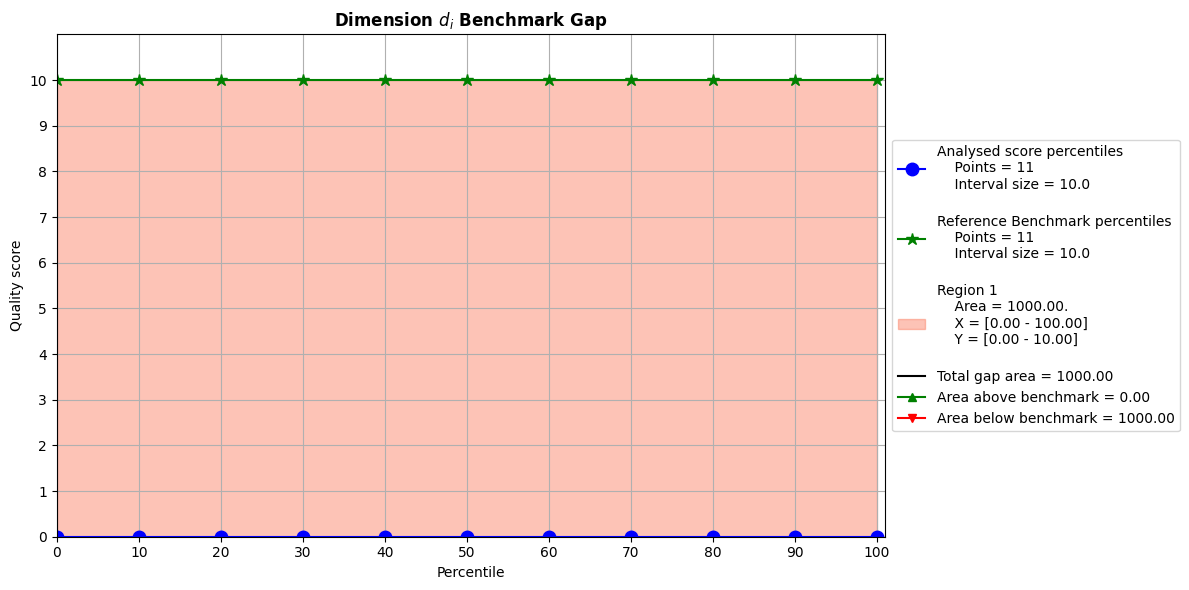

percentiles reference_organization : [1. 1. 2. 3. 4. 5. 6. 7. 8. 8. 9.]
Percentiles analysed_organization: [0. 0. 1. 2. 3. 4. 4. 5. 6. 8. 8.]


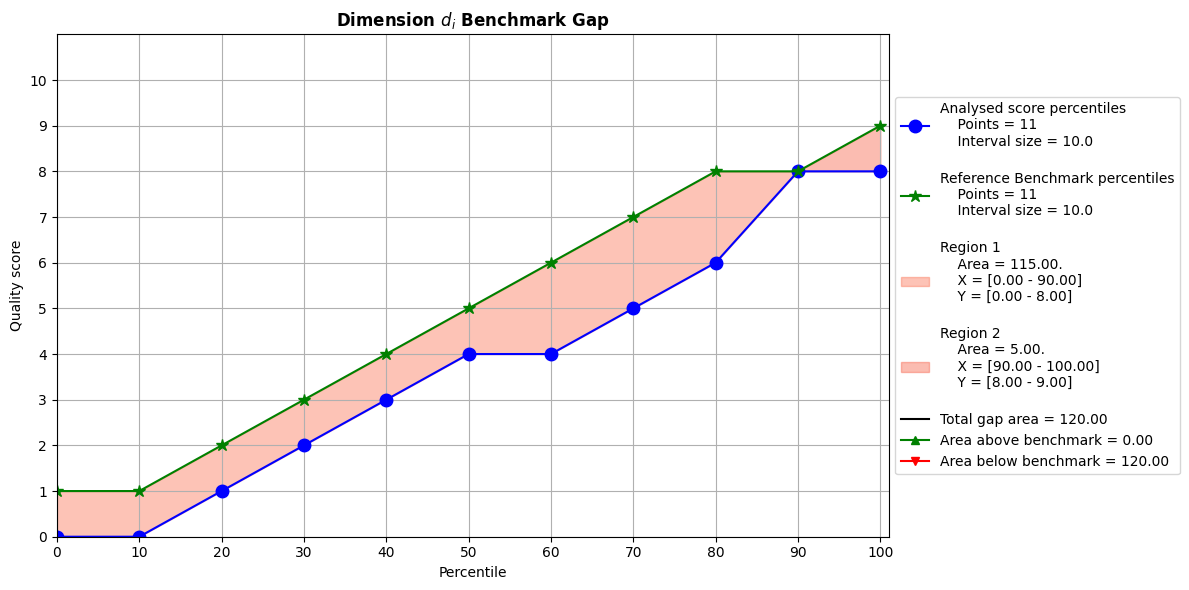

percentiles reference_organization : [0.   0.   1.   1.   2.   2.   3.   3.   4.   5.   5.   5.45 6.   7.
 7.   8.   8.   8.   9.   9.   9.  ]
Percentiles analysed_organization: [0.   0.   0.   1.05 2.4  3.25 3.7  4.   4.   4.   4.   4.   4.4  4.85
 5.   5.   5.   5.   5.1  5.55 6.  ]


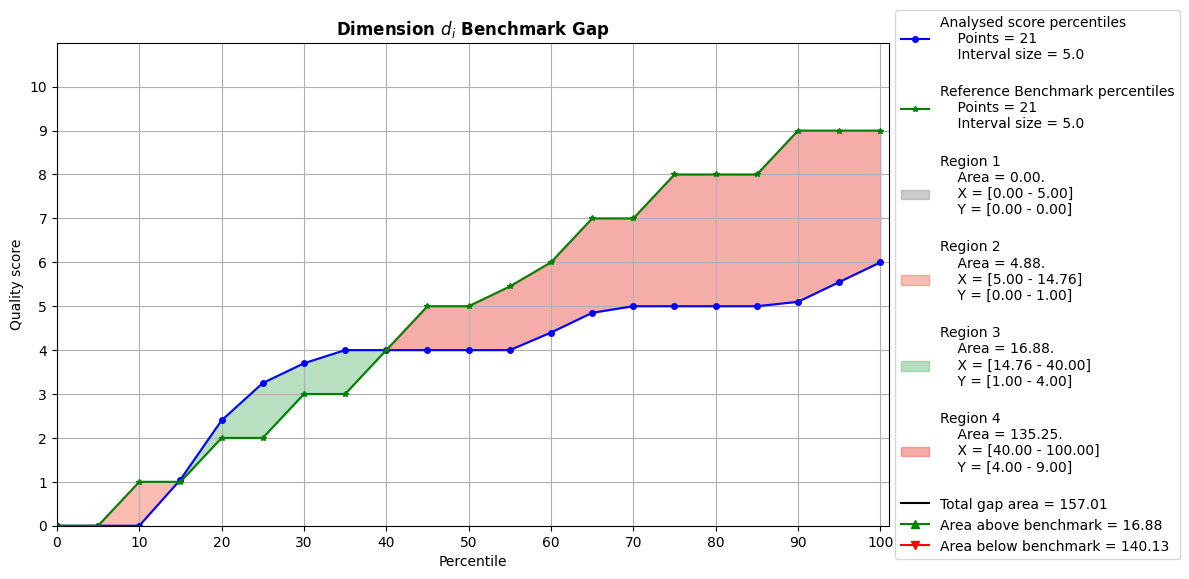

percentiles reference_organization : [0.  0.  1.  2.  3.  4.  5.  6.3 7.  8.  9. ]
Percentiles analysed_organization: [0.  0.  1.  2.  2.  3.  3.  3.  4.  4.  5.  5.  5.4 6.  7.  7.  7.  8.
 9.  9.  9. ]


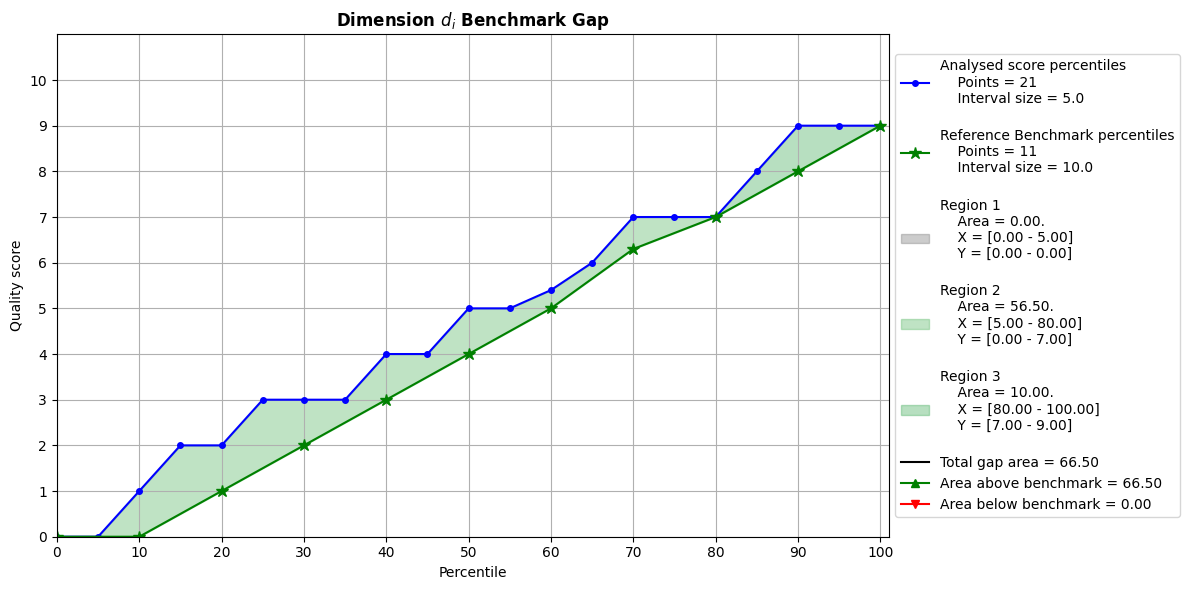

percentiles reference_organization : [1.  1.  1.  2.  3.  4.  5.  5.3 6.  7.  7. ]
Percentiles analysed_organization: [3. 4. 4. 5. 6. 6. 7. 8. 9. 9. 9.]


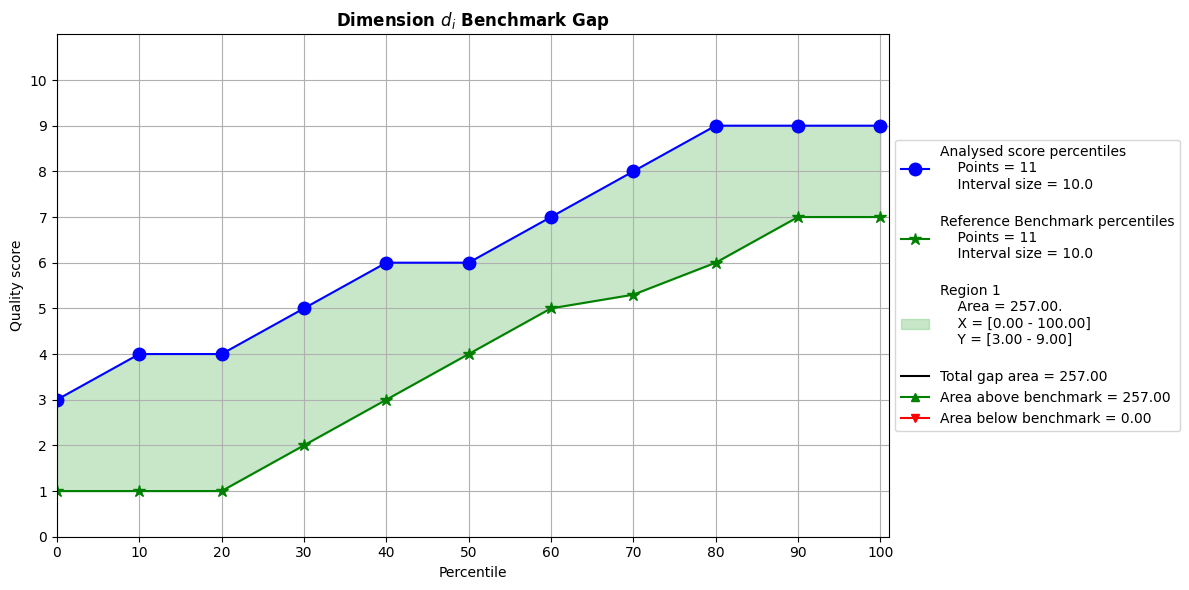

percentiles reference_organization : [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
Percentiles analysed_organization: [5. 5. 5. 5. 5. 5. 5. 5. 5. 5. 5.]


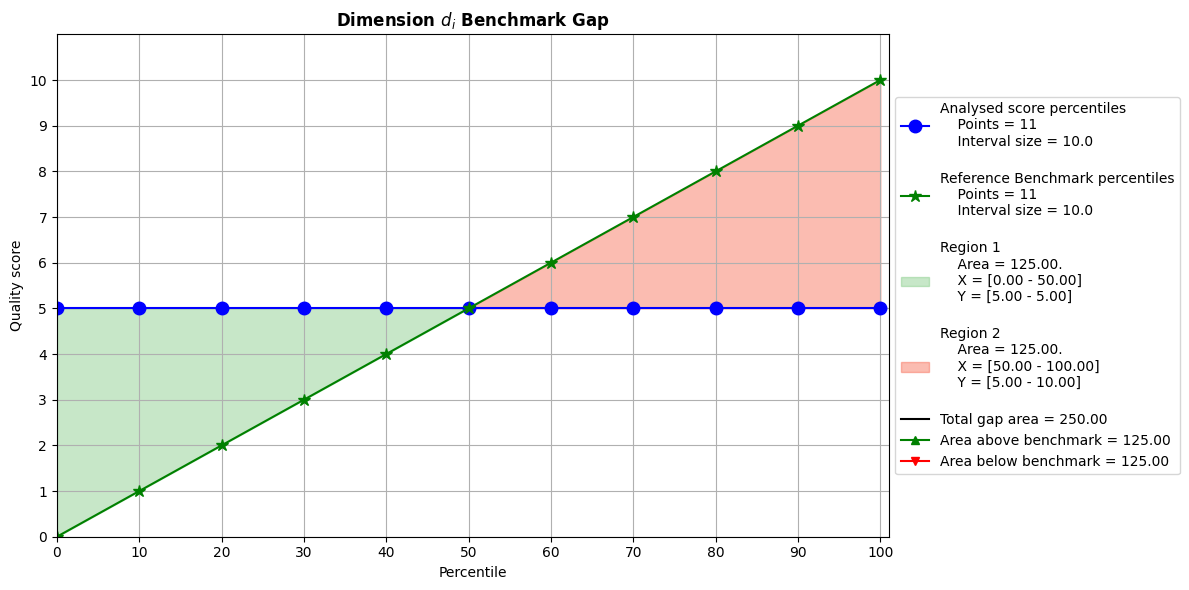

In [ ]:
np.random.seed(42) # Seed for reproducibility

plot_i = 1
for example in [0,1,2,3,4,5]:

  if example == 0:
    reference_organization_scores = np.array([10,10,10,10,10,10,10,10,10,10,10,10])
    analysed_organization_scores  = np.sort([0,0,0,0,0,0,0,0,0,0,0,0])
    reference_organization_percentiles = np.percentile(reference_organization_scores, list(range(0, 101, 10)))
    analysed_organization_percentiles  = np.percentile(analysed_organization_scores,  list(range(0, 101, 10)))
  if example == 1:
    reference_organization_scores = np.sort(np.random.randint(low=1, high=10, size=400))
    analysed_organization_scores  = np.sort(np.random.randint(low=0, high=9, size=250))
    reference_organization_percentiles = np.percentile(reference_organization_scores, list(range(0, 101, 10)))
    analysed_organization_percentiles  = np.percentile(analysed_organization_scores,  list(range(0, 101, 10)))
  if example == 2:
    reference_organization_scores = np.sort(np.random.randint(low=0, high=10, size=100))
    analysed_organization_scores  = np.sort(np.random.randint(low=0, high=7.5, size=10))
    reference_organization_percentiles = np.percentile(reference_organization_scores, list(range(0, 101, 5)))
    analysed_organization_percentiles  = np.percentile(analysed_organization_scores,  list(range(0, 101, 5)))
  if example == 3:
    reference_organization_scores = np.sort(np.random.randint(low=0, high=10, size=100))
    analysed_organization_scores  = np.sort(np.random.randint(low=0, high=10, size=85))
    reference_organization_percentiles = np.percentile(reference_organization_scores, list(range(0, 101, 10)))
    analysed_organization_percentiles  = np.percentile(analysed_organization_scores,  list(range(0, 101, 5)))
  if example == 4:
    reference_organization_scores = np.sort(np.random.randint(low=1, high=8, size=100))
    analysed_organization_scores  = np.sort(np.random.randint(low=3, high=10, size=85))
    reference_organization_percentiles = np.percentile(reference_organization_scores, list(range(0, 101, 10)))
    analysed_organization_percentiles  = np.percentile(analysed_organization_scores,  list(range(0, 101, 10)))
  if example == 5:
    reference_organization_scores = np.array([0,1,2,3,4,5,6,7,8,9,10])
    analysed_organization_scores  = np.sort([5,5,5,5,5,5,5,5,5,5])
    reference_organization_percentiles = np.percentile(reference_organization_scores, list(range(0, 101, 10)))
    analysed_organization_percentiles  = np.percentile(analysed_organization_scores,  list(range(0, 101, 10)))




  # Show the sorted arrays
  print("percentiles reference_organization :", reference_organization_percentiles)
  print("Percentiles analysed_organization:", analysed_organization_percentiles)

  # Example usage
  step_10_percentiles_benchmark_gap_plot(analysed_organization_percentiles, reference_organization_percentiles,out_name="Benchark_Gap_Plot_"+str(plot_i))
  plot_i += 1

# **Role Gap Plot**

## **Code**

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D



def plot_role_gaps(organizations, data_consumers_mean_scores, IS_Professionals_mean_scores,out_name="Figure"):
  """
  Input
  organizations: name of the organizations to be used as tick-labels in x axis.
  data_consumers_mean_scores:   Array containing the mean of scores assigned by data consumers in each organization.
  IS_Professionals_mean_scores: Array containing the mean of scores assigned by IS professionals in each organization.

  Outplut
  Plots the role gap.

  """

  # Example categories

  # Map categories to numeric positions
  x = np.arange(len(organizations))

  plt.figure(figsize=(6, 4))

  for xi, yi1, yi2 in zip(x, data_consumers_mean_scores, IS_Professionals_mean_scores):
        # Draw vertical line
      if yi1 < yi2:
        line_color = "#D81B60"
      else:
        line_color = "#004D40"
      # vertical line connecting the two points
      plt.plot([xi, xi], [yi1, yi2], color=line_color, linewidth=2)
      # points with different markers
      plt.scatter(xi, yi1, color='black', s=80, marker='o', zorder=3)
      plt.scatter(xi, yi2, color='black', s=70, marker='s', zorder=3)

  # Set x-axis to show category labels
  plt.xticks(x, organizations)

  # Optional legend
  legend_elements = [
      Line2D([0], [0], marker='s', color='w', label='IS Professionals mean score', markerfacecolor='black', markersize=10),
      Line2D([0], [0], marker='o', color='w', label='Data consumers mean score', markerfacecolor='black', markersize=11)
  ]
  plt.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5))

  plt.xlabel("Organization")
  plt.ylabel("Quality Score")
  plt.title("Role score Gaps",fontweight='bold')
  plt.grid(True)
  plt.tight_layout()
  plt.savefig(out_name + ".png", dpi=600, bbox_inches="tight")
  plt.show()

## **Example**

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42) # Seed for reproducibility

mean_IS_Professional_scores_list = []
mean_Consumer_scores_list = []

for i in range(4):

  IS_Professional_scores = np.random.randint(low=0, high=10, size=40)
  Consumer_scores        = np.random.randint(low=0, high=10-i, size=50)

  mean_IS_Professional_scores = np.mean(IS_Professional_scores)
  mean_IS_Professional_scores_list.append(mean_IS_Professional_scores)
  mean_Consumer_scores = np.mean(Consumer_scores)
  mean_Consumer_scores_list.append(mean_Consumer_scores)


mean_score_by_role = {
    'Organization': ['A', 'B', 'C', 'D'],
    'mean_IS_Professional_scores': mean_IS_Professional_scores_list,
    'mean_Consumer_scores': mean_Consumer_scores_list
}


df_mean_score_by_role = pd.DataFrame(mean_score_by_role)
df_mean_score_by_role

,Organization,mean_IS_Professional_scores,mean_Consumer_scores
0,A,4.650,4.92
1,B,4.700,3.76
2,C,4.175,3.74
3,D,3.125,2.84


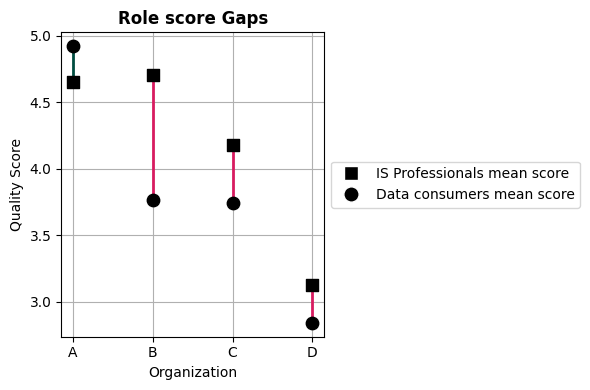

In [ ]:
plot_role_gaps(df_mean_score_by_role['Organization'], df_mean_score_by_role['mean_Consumer_scores'], df_mean_score_by_role['mean_IS_Professional_scores'],out_name="Role_Gap_plot")

# **Organization Role Gaps by dimension**

## **Code**

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_organization_role_gaps_by_dimension(df_dimensions_scores, out_name="Figure"):
  """
  Input:

  df_dimensions_scores --> Dataframe with the following constraints:
       Each row corresponds to a participant.
       Each row has in the Role column the String for the role, and for
       all other columns the the answered scorings given for diemnsions.
       [Role, Dimension_1_score,	Dimension_2_score, ...]

  Output
  Plot showing as lines the the average scorings per role group.
  The average over the total of participants is also plotted.

  """

  dimensions_mean_scores_by_role_df = df_dimensions_scores.groupby('Role', as_index=False).mean()
  dimension_scores = dimensions_mean_scores_by_role_df.iloc[:, 1:]

  role_names = list(dimensions_mean_scores_by_role_df["Role"].unique())
  role_counts = df_dimensions_scores["Role"].value_counts()
  role_ratio = (role_counts/role_counts.sum())*100

  dimension_names = dimension_scores.columns.tolist()
  x = np.arange(len(dimension_names))
  i = 0

  colors = plt.cm.tab20.colors
  box_text = "\nRole Distributions\n"
  for scores_i in dimension_scores.itertuples(index=False, name=None):
    plt.plot(x, scores_i, marker='o',label= role_names[i], color=colors[i % len(colors)])
    box_text += role_names[i] +": "+ str(role_counts[i].round(2)) + " (" + str(role_ratio[i].round(2))+"%)\n"
    i +=1

  plt.plot(x, df_dimensions_scores.iloc[:, 1:].mean().to_numpy(), marker='D',label="All participants average", color="Black")

  ax = plt.gca()
  # include automatic legends in legend Box
  handles, labels = ax.get_legend_handles_labels()

  # Manual addition to legend Box of other metrics.
  handles.append(Line2D([], [], color='none'))
  labels.append(box_text)
  plt.xticks(x,dimension_names, rotation=90, ha='right')
  plt.ylim(0, 11)
  plt.grid(True)
  plt.title('Role average scores',fontweight='bold')
  plt.ylabel("Quality score")
  plt.legend(handles, labels, loc='center left', bbox_to_anchor=(1, 0.5))
  plt.savefig(out_name + ".png", dpi=600, bbox_inches="tight")
  plt.show()

## **Example**

In [ ]:
import pandas as pd
np.random.seed(42) # Seed for reproducibility

mean_IS_Professional_scores_list = []
mean_Consumer_scores_list = []
roles = ["Data consumer", "Data collector", "Data custodian"]
participants_role = np.random.choice(roles, size=160)

scores = []
for i in range(7):
  d_i_scores = np.random.randint(low=0, high=10, size=160)
  scores.append(d_i_scores)


dimensions_scores = {
    'Role': participants_role,
    'Dimension_1_score': scores[0],
    'Dimension_2_score': scores[1],
    'Dimension_3_score': scores[2],
    'Dimension_4_score': scores[3],
    'Dimension_5_score': scores[4],
    'Dimension_6_score': scores[5],
    'Dimension_7_score': scores[6]
}


df_dimensions_scores = pd.DataFrame(dimensions_scores)
df_dimensions_scores[4:9]

,Role,Dimension_1_score,Dimension_2_score,Dimension_3_score,Dimension_4_score,Dimension_5_score,Dimension_6_score,Dimension_7_score
4,Data consumer,8,4,1,9,3,8,3
5,Data consumer,4,5,2,1,7,0,0
6,Data custodian,5,2,1,4,5,0,7
7,Data collector,3,8,2,8,9,6,6
8,Data custodian,9,4,6,3,6,1,6


/tmp/ipython-input-1491685380.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  box_text += role_names[i] +": "+ str(role_counts[i].round(2)) + " (" + str(role_ratio[i].round(2))+"%)\n"


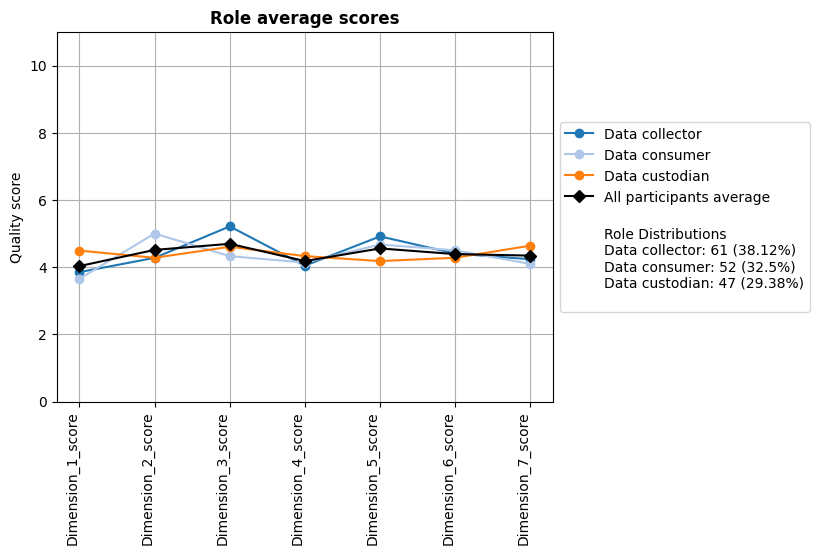

In [ ]:
plot_organization_role_gaps_by_dimension(df_dimensions_scores, out_name="Role_average_scores")